In [1]:
import os
import gc
import joblib
import json
from datetime import datetime

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import pyarrow

In [2]:
def clear_memory(*args):
    # useful when messing around with dataset without filling ram
    # the dataset used here is pretty large compare to normal datasets
    for var in args:
        if var in globals():
            del globals()[var]
    gc.collect()

## load datasets and inspect structure

In [3]:
DATA_DIR = "../data"
MIRAI_DATA = os.path.join(DATA_DIR, "Mirai_dataset.csv.gz")
MIRAI_LABELS = os.path.join(DATA_DIR, "Mirai_labels.csv.gz")
OS_DATA = os.path.join(DATA_DIR, "OS%20Scan_dataset.csv.gz")
OS_LABELS = os.path.join(DATA_DIR, "OS%20Scan_labels.csv.gz")

def get_lazy_frame(file_path):
    return pl.scan_csv(file_path, has_header=False)

def print_dataset_attributes(lazy_df, name):
    print(f"--- Attributes for: {name} ---")
    
    row_count = lazy_df.select(pl.len()).collect().item()
    col_count = len(lazy_df.columns)
    
    print(f"Shape: ({row_count}, {col_count})")
    print("-" * 30 + "\n")

mirai_data_lf = get_lazy_frame(MIRAI_DATA)
mirai_labels_lf = get_lazy_frame(MIRAI_LABELS)
os_data_lf = get_lazy_frame(OS_DATA)
os_labels_lf = get_lazy_frame(OS_LABELS)

print_dataset_attributes(mirai_data_lf, "Mirai Dataset")
print_dataset_attributes(mirai_labels_lf, "Mirai Labels")
print_dataset_attributes(os_data_lf, "OS Scan Dataset")
print_dataset_attributes(os_labels_lf, "OS Scan Labels")

--- Attributes for: Mirai Dataset ---


/tmp/ipykernel_2517/359218950.py:14: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  col_count = len(lazy_df.columns)


Shape: (764137, 116)
------------------------------

--- Attributes for: Mirai Labels ---
Shape: (764137, 1)
------------------------------

--- Attributes for: OS Scan Dataset ---
Shape: (1697851, 115)
------------------------------

--- Attributes for: OS Scan Labels ---
Shape: (1697852, 2)
------------------------------



In [4]:
def peek_content(lazy_df, name):
    print(f"--- Top 5 rows of {name} ---")
    print(lazy_df.head(5).collect())
    print("\n")

peek_content(os_data_lf, "OS Scan Dataset")
peek_content(os_labels_lf, "OS Scan Labels")

--- Top 5 rows of OS Scan Dataset ---
shape: (5, 115)
┌──────────┬──────────┬────────────┬──────────┬───┬────────────┬───────────┬───────────┬───────────┐
│ column_1 ┆ column_2 ┆ column_3   ┆ column_4 ┆ … ┆ column_112 ┆ column_11 ┆ column_11 ┆ column_11 │
│ ---      ┆ ---      ┆ ---        ┆ ---      ┆   ┆ ---        ┆ 3         ┆ 4         ┆ 5         │
│ f64      ┆ f64      ┆ f64        ┆ f64      ┆   ┆ f64        ┆ ---       ┆ ---       ┆ ---       │
│          ┆          ┆            ┆          ┆   ┆            ┆ f64       ┆ f64       ┆ f64       │
╞══════════╪══════════╪════════════╪══════════╪═══╪════════════╪═══════════╪═══════════╪═══════════╡
│ 1.0      ┆ 1294.0   ┆ 0.0        ┆ 1.0      ┆ … ┆ 1294.0     ┆ 0.0       ┆ 0.0       ┆ 0.0       │
│ 1.999871 ┆ 1294.0   ┆ 2.3283e-10 ┆ 1.999923 ┆ … ┆ 1294.0     ┆ 2.3283e-1 ┆ 0.0       ┆ 0.0       │
│          ┆          ┆            ┆          ┆   ┆            ┆ 0         ┆           ┆           │
│ 2.999324 ┆ 1294.0   ┆ 0.0        ┆ 

In [5]:
peek_content(mirai_data_lf, "Mirai Dataset")
peek_content(mirai_labels_lf, "Mirai Labels")

--- Top 5 rows of Mirai Dataset ---
shape: (5, 116)
┌──────────┬──────────┬──────────┬────────────┬───┬────────────┬───────────┬───────────┬───────────┐
│ column_1 ┆ column_2 ┆ column_3 ┆ column_4   ┆ … ┆ column_113 ┆ column_11 ┆ column_11 ┆ column_11 │
│ ---      ┆ ---      ┆ ---      ┆ ---        ┆   ┆ ---        ┆ 4         ┆ 5         ┆ 6         │
│ i64      ┆ f64      ┆ f64      ┆ f64        ┆   ┆ f64        ┆ ---       ┆ ---       ┆ ---       │
│          ┆          ┆          ┆            ┆   ┆            ┆ f64       ┆ f64       ┆ f64       │
╞══════════╪══════════╪══════════╪════════════╪═══╪════════════╪═══════════╪═══════════╪═══════════╡
│ 0        ┆ 1.0      ┆ 60.0     ┆ 0.0        ┆ … ┆ 60.0       ┆ 0.0       ┆ 0.0       ┆ 0.0       │
│ 1        ┆ 1.999983 ┆ 60.0     ┆ 0.0        ┆ … ┆ 60.0       ┆ 0.0       ┆ 0.0       ┆ 0.0       │
│ 2        ┆ 1.0      ┆ 86.0     ┆ 0.0        ┆ … ┆ 86.0       ┆ 0.0       ┆ 0.0       ┆ 0.0       │
│ 3        ┆ 1.999272 ┆ 86.0     ┆ 9.09

In [6]:
print("--- Mirai Data Columns ---")
print(mirai_data_lf.collect_schema())

print("\n--- OS Scan Data Columns ---")
print(os_data_lf.collect_schema())

--- Mirai Data Columns ---
Schema({'column_1': Int64, 'column_2': Float64, 'column_3': Float64, 'column_4': Float64, 'column_5': Float64, 'column_6': Float64, 'column_7': Float64, 'column_8': Float64, 'column_9': Float64, 'column_10': Float64, 'column_11': Float64, 'column_12': Float64, 'column_13': Float64, 'column_14': Float64, 'column_15': Float64, 'column_16': Float64, 'column_17': Float64, 'column_18': Float64, 'column_19': Float64, 'column_20': Float64, 'column_21': Float64, 'column_22': Float64, 'column_23': Float64, 'column_24': Float64, 'column_25': Float64, 'column_26': Float64, 'column_27': Float64, 'column_28': Float64, 'column_29': Float64, 'column_30': Float64, 'column_31': Float64, 'column_32': Float64, 'column_33': Float64, 'column_34': Float64, 'column_35': Float64, 'column_36': Float64, 'column_37': Float64, 'column_38': Float64, 'column_39': Float64, 'column_40': Float64, 'column_41': Float64, 'column_42': Float64, 'column_43': Float64, 'column_44': Float64, 'column_

## datasets cleanup and merge

In [7]:
def get_cleaned_mirai(path):
    return (
        pl.scan_csv(path, has_header=False)
        .drop("column_1")
        .rename({f"column_{i}": f"column_{i-1}" for i in range(2, 117)})
    )

def get_cleaned_os_labels(path):
    return(
        pl.scan_csv(path, has_header=False)
        .slice(1)
        .select([
            pl.col("column_2")
            .cast(pl.Int64) 
            .alias("target") 
        ])
    )

mirai_data_lf = get_cleaned_mirai(MIRAI_DATA)
mirai_targets = pl.scan_csv(MIRAI_LABELS, has_header=False).rename({"column_1": "target"})
os_labels_lf = get_cleaned_os_labels(OS_LABELS)


print_dataset_attributes(mirai_data_lf, "Mirai Dataset")
print_dataset_attributes(mirai_labels_lf, "Mirai Labels")
print_dataset_attributes(os_data_lf, "OS Scan Dataset")
print_dataset_attributes(os_labels_lf, "OS Scan Labels")

--- Attributes for: Mirai Dataset ---


/tmp/ipykernel_2517/359218950.py:14: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  col_count = len(lazy_df.columns)


Shape: (764137, 115)
------------------------------

--- Attributes for: Mirai Labels ---
Shape: (764137, 1)
------------------------------

--- Attributes for: OS Scan Dataset ---
Shape: (1697851, 115)
------------------------------

--- Attributes for: OS Scan Labels ---
Shape: (1697851, 1)
------------------------------



In [8]:
def attach_label_to_df(lf, label_lf):
    return pl.concat([lf, label_lf], how="horizontal")
    
mirai_combined = attach_label_to_df(mirai_data_lf, mirai_targets)
os_combined = attach_label_to_df(os_data_lf, os_labels_lf)

final_lf = pl.concat([mirai_combined, os_combined], how="vertical")

final_lf.sink_parquet("../data/combined_kitsune.parquet")


# attempt 1

**This part is skippable**,   
after i dig into what each column for this dataset actually stands for and what they actually present,   
I figured I might need to approach this dataset in a different way.    

the main model evaluation and data pruning happened in attempt 2,   
but the eda part here still valid.

## correlation

In [9]:
gloabal_stats = (
    pl.scan_parquet("../data/combined_kitsune.parquet")
    .select([
        pl.all().mean().name.suffix("_mean"),
        pl.all().std().name.suffix("_std"),
        pl.all().max().name.suffix("_max")
    ])
    .collect()
)

print(gloabal_stats)

shape: (1, 348)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ column_1_ ┆ column_2_ ┆ column_3_ ┆ column_4_ ┆ … ┆ column_11 ┆ column_11 ┆ column_11 ┆ target_m │
│ mean      ┆ mean      ┆ mean      ┆ mean      ┆   ┆ 3_max     ┆ 4_max     ┆ 5_max     ┆ ax       │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ f64       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ i64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 104.67646 ┆ 695.90826 ┆ 56391.466 ┆ 164.38564 ┆ … ┆ 425756.24 ┆ 112.49000 ┆ 0.875271  ┆ 1        │
│ 8         ┆ 7         ┆ 114       ┆ 8         ┆   ┆ 9996      ┆ 6         ┆           ┆          │
└───────────┴───────────┴───────────┴───────────┴───┴───────────┴───────────┴───────────┴──────────┘


In [10]:
def get_stratified_sample(path, n_per_class=50000):
    lf = pl.scan_parquet(path)
    
    normal = lf.filter(pl.col("target") == 0).head(n_per_class).collect()
    attack = lf.filter(pl.col("target") == 1).head(n_per_class).collect()
    
    return pl.concat([normal, attack])

eda_df = get_stratified_sample("../data/combined_kitsune.parquet")

In [11]:
correlations = eda_df.corr().select([
    pl.all().exclude("target"), 
    pl.col("target")
]).filter(pl.col("target").abs() > 0.5)

print(correlations)

shape: (20, 116)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ column_1  ┆ column_2  ┆ column_3  ┆ column_4  ┆ … ┆ column_11 ┆ column_11 ┆ column_11 ┆ target   │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ 3         ┆ 4         ┆ 5         ┆ ---      │
│ f64       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ f64      │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 1.0       ┆ -0.429309 ┆ -0.052451 ┆ 0.995065  ┆ … ┆ -0.061259 ┆ -0.009649 ┆ -0.014134 ┆ 0.753384 │
│ 0.995065  ┆ -0.446959 ┆ -0.054658 ┆ 1.0       ┆ … ┆ -0.064541 ┆ -0.009327 ┆ -0.013227 ┆ 0.783785 │
│ 0.943977  ┆ -0.475236 ┆ -0.058314 ┆ 0.970345  ┆ … ┆ -0.070292 ┆ -0.009315 ┆ -0.012955 ┆ 0.832736 │
│ 0.849458  ┆ -0.461254 ┆ -0.056514 ┆ 0.885112  ┆ … ┆ -0.060452 ┆ -0.00305

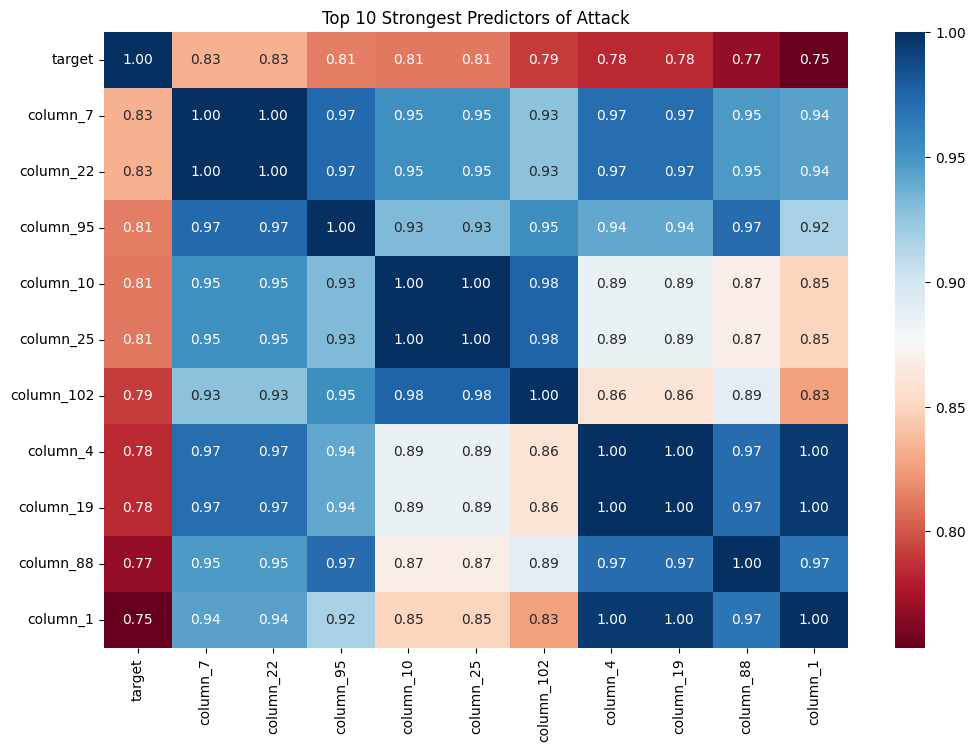

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = eda_df.corr()

feature_correlations = pl.DataFrame({
    "feature_name": eda_df.columns,
    "correlation_value": corr_matrix["target"]
})

top_features = (
    feature_correlations
    .with_columns(pl.col("correlation_value").abs().alias("abs_corr"))
    .sort("abs_corr", descending=True)
    .head(11) # Target itself + top 10
)["feature_name"].to_list()

plot_data = eda_df.select(top_features).corr().to_pandas()
plot_data.index = top_features

plt.figure(figsize=(12, 8))
sns.heatmap(
    eda_df.select(top_features).corr(), 
    annot=True, 
    cmap="RdBu",
    fmt=".2f",
    xticklabels=top_features,
    yticklabels=top_features
)
plt.title("Top 10 Strongest Predictors of Attack")
plt.show()

## cleanup highly correlate features

In [13]:
features_df = eda_df.select(top_features).drop("target")
corr_matrix = features_df.corr()

CORR_THRESHOLD = 0.95

redundant_pairs = []
columns = corr_matrix.columns
for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        if abs(corr_matrix[i, j]) > CORR_THRESHOLD:
            redundant_pairs.append((columns[i], columns[j], corr_matrix[i, j]))

print("Redundant pairs found:")
for p in redundant_pairs:
    print(f"{p[0]} and {p[1]} are {p[2]:.4f} correlated.")

Redundant pairs found:
column_7 and column_22 are 1.0000 correlated.
column_7 and column_95 are 0.9735 correlated.
column_7 and column_10 are 0.9518 correlated.
column_7 and column_25 are 0.9518 correlated.
column_7 and column_4 are 0.9703 correlated.
column_7 and column_19 are 0.9703 correlated.
column_22 and column_95 are 0.9735 correlated.
column_22 and column_10 are 0.9518 correlated.
column_22 and column_25 are 0.9518 correlated.
column_22 and column_4 are 0.9703 correlated.
column_22 and column_19 are 0.9703 correlated.
column_95 and column_102 are 0.9537 correlated.
column_95 and column_88 are 0.9717 correlated.
column_10 and column_25 are 1.0000 correlated.
column_10 and column_102 are 0.9764 correlated.
column_25 and column_102 are 0.9764 correlated.
column_4 and column_19 are 1.0000 correlated.
column_4 and column_88 are 0.9715 correlated.
column_4 and column_1 are 0.9951 correlated.
column_19 and column_88 are 0.9715 correlated.
column_19 and column_1 are 0.9951 correlated.


In [14]:
# dropping features that are highly correlate
# to make the engine lightweight and low false negative(no obvious attack)
import networkx as nx

G = nx.Graph()
for f1, f2, weight in redundant_pairs:
    G.add_edge(f1, f2)

redundant_groups = list(nx.connected_components(G))

to_drop = []
print("--- Selection Process ---")

for group in redundant_groups:
    group_list = list(group)
    
    group_scores = (
        feature_correlations
        .filter(pl.col("feature_name").is_in(group_list))
        .with_columns(pl.col("correlation_value").abs().alias("abs_corr"))
        .sort("abs_corr", descending=True)
    )
    
    # The first one is our "Winner"
    winner = group_scores["feature_name"][0]
    losers = group_scores["feature_name"][1:].to_list()
    
    print(f"Group: {group_list}")
    print(f"  > Winner: {winner} (Keep)")
    print(f"  > Losers: {losers} (Drop)")
    
    to_drop.extend(losers)

cleaned_corr_features = [col for col in eda_df.columns if col not in to_drop and col != "target"]

print(f"\nOriginal count: {len(eda_df.columns) - 1}")
print(f"Dropped: {len(to_drop)}")
print(f"Remaining: {len(cleaned_corr_features)}")

--- Selection Process ---
Group: ['column_7', 'column_4', 'column_88', 'column_1', 'column_19', 'column_10', 'column_95', 'column_102', 'column_25', 'column_22']
  > Winner: column_7 (Keep)
  > Losers: ['column_22', 'column_95', 'column_10', 'column_25', 'column_102', 'column_4', 'column_19', 'column_88', 'column_1'] (Drop)

Original count: 115
Dropped: 9
Remaining: 106


## missing value and distribution check

In [15]:
null_counts = (
    pl.scan_parquet("../data/combined_kitsune.parquet")
    .select([
        pl.col(c).null_count().alias(c) for c in cleaned_corr_features
    ])
    .collect()
)
null_counts

column_2,column_3,column_5,column_6,column_7,column_8,column_9,column_11,column_12,column_13,column_14,column_15,column_16,column_17,column_18,column_20,column_21,column_23,column_24,column_26,column_27,column_28,column_29,column_30,column_31,column_32,column_33,column_34,column_35,column_36,column_37,column_38,column_39,column_40,column_41,column_42,column_43,…,column_76,column_77,column_78,column_79,column_80,column_81,column_82,column_83,column_84,column_85,column_86,column_87,column_89,column_90,column_91,column_92,column_93,column_94,column_96,column_97,column_98,column_99,column_100,column_101,column_103,column_104,column_105,column_106,column_107,column_108,column_109,column_110,column_111,column_112,column_113,column_114,column_115
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [16]:
class_counts = (
    pl.scan_parquet("../data/combined_kitsune.parquet")
    .group_by("target")
    .len()
    .collect()
)
print(class_counts)

shape: (2, 2)
┌────────┬─────────┐
│ target ┆ len     │
│ ---    ┆ ---     │
│ i64    ┆ u32     │
╞════════╪═════════╡
│ 1      ┆ 708216  │
│ 0      ┆ 1753772 │
└────────┴─────────┘


In [17]:
total_row_count = (
    pl.scan_parquet("../data/combined_kitsune.parquet")
    .select(pl.len())
    .collect()
    .item()
)
print(total_row_count)

2461988


In [18]:
single_value_count = (
    pl.scan_parquet("../data/combined_kitsune.parquet")
    .select([
        (pl.col(c).max() == pl.col(c).min()).alias(c) 
        for c in cleaned_corr_features
    ])
    .collect()
)
single_value_count

column_2,column_3,column_5,column_6,column_7,column_8,column_9,column_11,column_12,column_13,column_14,column_15,column_16,column_17,column_18,column_20,column_21,column_23,column_24,column_26,column_27,column_28,column_29,column_30,column_31,column_32,column_33,column_34,column_35,column_36,column_37,column_38,column_39,column_40,column_41,column_42,column_43,…,column_76,column_77,column_78,column_79,column_80,column_81,column_82,column_83,column_84,column_85,column_86,column_87,column_89,column_90,column_91,column_92,column_93,column_94,column_96,column_97,column_98,column_99,column_100,column_101,column_103,column_104,column_105,column_106,column_107,column_108,column_109,column_110,column_111,column_112,column_113,column_114,column_115
bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,…,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool
false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,…,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false


In [19]:
negative_counts = (
    pl.scan_parquet("../data/combined_kitsune.parquet")
    .select([
        (pl.col(c) < 0).sum().alias(c) 
        for c in cleaned_corr_features
    ])
    .collect()
)

print(negative_counts)

shape: (1, 106)
┌──────────┬──────────┬──────────┬──────────┬───┬────────────┬────────────┬────────────┬───────────┐
│ column_2 ┆ column_3 ┆ column_5 ┆ column_6 ┆ … ┆ column_112 ┆ column_113 ┆ column_114 ┆ column_11 │
│ ---      ┆ ---      ┆ ---      ┆ ---      ┆   ┆ ---        ┆ ---        ┆ ---        ┆ 5         │
│ u32      ┆ u32      ┆ u32      ┆ u32      ┆   ┆ u32        ┆ u32        ┆ u32        ┆ ---       │
│          ┆          ┆          ┆          ┆   ┆            ┆            ┆            ┆ u32       │
╞══════════╪══════════╪══════════╪══════════╪═══╪════════════╪════════════╪════════════╪═══════════╡
│ 0        ┆ 0        ┆ 0        ┆ 0        ┆ … ┆ 0          ┆ 0          ┆ 633291     ┆ 627955    │
└──────────┴──────────┴──────────┴──────────┴───┴────────────┴────────────┴────────────┴───────────┘


## training

In [20]:
TRAINING_SPLIT_END = int(total_row_count * 0.90)
TEST_SPLIT_END = TRAINING_SPLIT_END + int(total_row_count * 0.05)

RANDOM_SEED = 45
BATCH_SIZE = 200_000

model_dir = "../models"
target = "target"

columns_to_load = cleaned_corr_features + [target]
lf = (
    pl.scan_parquet("../data/combined_kitsune.parquet")
    .select(columns_to_load)
    .with_columns([
        pl.col(cleaned_corr_features).cast(pl.Float32)
    ])
)

In [21]:
print(lf.collect_schema().names())
print("-" * 50)
print(lf.collect_schema())

['column_2', 'column_3', 'column_5', 'column_6', 'column_7', 'column_8', 'column_9', 'column_11', 'column_12', 'column_13', 'column_14', 'column_15', 'column_16', 'column_17', 'column_18', 'column_20', 'column_21', 'column_23', 'column_24', 'column_26', 'column_27', 'column_28', 'column_29', 'column_30', 'column_31', 'column_32', 'column_33', 'column_34', 'column_35', 'column_36', 'column_37', 'column_38', 'column_39', 'column_40', 'column_41', 'column_42', 'column_43', 'column_44', 'column_45', 'column_46', 'column_47', 'column_48', 'column_49', 'column_50', 'column_51', 'column_52', 'column_53', 'column_54', 'column_55', 'column_56', 'column_57', 'column_58', 'column_59', 'column_60', 'column_61', 'column_62', 'column_63', 'column_64', 'column_65', 'column_66', 'column_67', 'column_68', 'column_69', 'column_70', 'column_71', 'column_72', 'column_73', 'column_74', 'column_75', 'column_76', 'column_77', 'column_78', 'column_79', 'column_80', 'column_81', 'column_82', 'column_83', 'colu

In [22]:
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import SGDClassifier

log_reg = SGDClassifier(
    loss='log_loss', 
    learning_rate='optimal', 
    penalty='l2'
)

svm_linear = SGDClassifier(
    loss='hinge', 
    learning_rate='optimal', 
    penalty='l2'
)

scaler = RobustScaler()

def symlog_transform(lf, features):
    return lf.with_columns([
        (pl.col(f).sign() * (pl.col(f).abs() + 1).log()).alias(f)
        for f in features
    ])

lf_transformed = symlog_transform(lf, cleaned_corr_features)

print("Calculating scaling parameters...")
sample_batch = lf_transformed.slice(0, 100_000).collect()
scaler.fit(sample_batch.select(cleaned_corr_features).to_numpy())
del sample_batch # Free memory immediately
gc.collect()

print("Training models...")
for offset in range(0, TRAINING_SPLIT_END, BATCH_SIZE):
    batch = lf_transformed.slice(offset, min(BATCH_SIZE, TRAINING_SPLIT_END - offset)).collect()
    X_scaled = scaler.transform(batch.select(cleaned_corr_features).to_numpy())
    y = batch[target].to_numpy()

    log_reg.partial_fit(X_scaled, y, classes=[0, 1])
    svm_linear.partial_fit(X_scaled, y, classes=[0, 1])

    del batch, X_scaled, y
    gc.collect()

print("Training Done. Saving artifacts...")
os.makedirs(model_dir, exist_ok=True)

joblib.dump(log_reg, f"{model_dir}/logistic_regression.joblib")
joblib.dump(svm_linear, f"{model_dir}/svm_linear.joblib")
joblib.dump(scaler, f"{model_dir}/scaler.joblib")

print(f"All artifacts saved to {model_dir}/.")

Calculating scaling parameters...
Training models...
Training Done. Saving artifacts...
All artifacts saved to ../models/.


In [23]:
import lightgbm as lgb
import xgboost as xgb

lgb_model = None
xgb_model = None

lgb_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'learning_rate': 0.05 # Lower learning rate is better for many small batches
}

xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'learning_rate': 0.05
}

for offset in range(0, TRAINING_SPLIT_END, BATCH_SIZE):
    batch = lf_transformed.slice(offset, min(BATCH_SIZE, TRAINING_SPLIT_END - offset)).collect()
    X_batch = scaler.transform(batch.select(cleaned_corr_features).to_numpy())
    y_batch = batch[target].to_numpy()

    lgb_train = lgb.Dataset(X_batch, label=y_batch)
    lgb_model = lgb.train(
        lgb_params,
        lgb_train,
        num_boost_round=5,
        init_model=lgb_model,
        keep_training_booster=True
    )

    # --- XGBoost ---
    dtrain = xgb.DMatrix(X_batch, label=y_batch)
    xgb_model = xgb.train(
        xgb_params,
        dtrain,
        num_boost_round=5,
        xgb_model=xgb_model
    )
    
    del batch, X_batch, y_batch, dtrain, lgb_train
    gc.collect()

lgb_model.save_model(f"{model_dir}/lightgbm_triage.txt")
xgb_model.save_model(f"{model_dir}/xgboost_triage.json")
joblib.dump(scaler, f"{model_dir}/robust_scaler.joblib")

['../models/robust_scaler.joblib']

In [24]:
training_metadata = {
    "timestamp": datetime.now().isoformat(),
    "features_count": len(cleaned_corr_features),
    "features_list": cleaned_corr_features,
    "target": target,
    "transform": "symlog",
    "scaler": "RobustScaler",
    "batch_size": BATCH_SIZE
}

with open(f"{model_dir}/training_metadata.json", "w") as f:
    json.dump(training_metadata, f, indent=4)

## model evaluation

In [25]:
from sklearn.metrics import classification_report, roc_auc_score
import time

In [26]:
with open(f"{model_dir}/training_metadata.json", "r") as f:
    meta = json.load(f)

features = meta["features_list"]
target = meta["target"]

print("Loading models...")
scaler = joblib.load(f"{model_dir}/scaler.joblib")
log_reg = joblib.load(f"{model_dir}/logistic_regression.joblib")
svm_linear = joblib.load(f"{model_dir}/svm_linear.joblib")
lgb_model = lgb.Booster(model_file=f"{model_dir}/lightgbm_triage.txt")
xgb_model = xgb.Booster()
xgb_model.load_model(f"{model_dir}/xgboost_triage.json")

Loading models...


In [27]:
val_start = int(total_row_count * 0.85) 
val_size = int(total_row_count * 0.05)

val_batch = (
    pl.scan_parquet("../data/combined_kitsune.parquet")
    .slice(val_start, val_size)
    .select(features + [target])
)

val_transformed = symlog_transform(val_batch, features).collect()

X_val_raw = val_transformed.select(features).to_numpy()
X_val = scaler.transform(X_val_raw)
y_val = val_transformed[target].to_numpy()

In [28]:
def evaluate(name, y_true, y_probs, y_pred):
    print(f"\n--- {name} ---")
    print(f"AUC-ROC: {roc_auc_score(y_true, y_probs):.4f}")
    print(classification_report(y_true, y_pred))

In [29]:
start = time.time()
lr_probs = log_reg.predict_proba(X_val)[:, 1]
lr_preds = log_reg.predict(X_val)
print(f"LR Latency: {time.time() - start:.4f}s")
evaluate("SGD Logistic Regression", y_val, lr_probs, lr_preds)

LR Latency: 0.0263s

--- SGD Logistic Regression ---
AUC-ROC: 0.9764
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     66898
           1       0.94      1.00      0.97     56201

    accuracy                           0.97    123099
   macro avg       0.97      0.97      0.97    123099
weighted avg       0.97      0.97      0.97    123099



In [30]:
start = time.time()
svm_scores = svm_linear.decision_function(X_val)
svm_preds = svm_linear.predict(X_val)
print(f"SVM Latency: {time.time() - start:.4f}s")
evaluate("SGD Linear SVM", y_val, svm_scores, svm_preds)

SVM Latency: 0.0182s

--- SGD Linear SVM ---
AUC-ROC: 0.9914
              precision    recall  f1-score   support

           0       1.00      0.89      0.94     66898
           1       0.88      1.00      0.94     56201

    accuracy                           0.94    123099
   macro avg       0.94      0.94      0.94    123099
weighted avg       0.95      0.94      0.94    123099



In [31]:
start = time.time()
lgb_probs = lgb_model.predict(X_val)
lgb_preds = (lgb_probs > 0.5).astype(int)
print(f"LGBM Latency: {time.time() - start:.4f}s")
evaluate("LightGBM", y_val, lgb_probs, lgb_preds)

LGBM Latency: 0.0220s

--- LightGBM ---
AUC-ROC: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66898
           1       1.00      1.00      1.00     56201

    accuracy                           1.00    123099
   macro avg       1.00      1.00      1.00    123099
weighted avg       1.00      1.00      1.00    123099



In [32]:
start = time.time()
dval = xgb.DMatrix(X_val)
xgb_probs = xgb_model.predict(dval)
xgb_preds = (xgb_probs > 0.5).astype(int)
print(f"XGB Latency: {time.time() - start:.4f}s")
evaluate("XGBoost", y_val, xgb_probs, xgb_preds)

XGB Latency: 0.0753s

--- XGBoost ---
AUC-ROC: 0.6064
              precision    recall  f1-score   support

           0       0.99      0.16      0.28     66898
           1       0.50      1.00      0.67     56201

    accuracy                           0.54    123099
   macro avg       0.75      0.58      0.47    123099
weighted avg       0.77      0.54      0.46    123099



In [33]:
importance_dict = dict(zip(lgb_model.feature_name(), lgb_model.feature_importance(importance_type='gain')))

sorted_importance = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)

for feat, score in sorted_importance[:20]:
    print(f"{feat}: {score:.4f}")

Column_77: 698765.0400
Column_9: 642116.7033
Column_73: 475074.2469
Column_10: 15526.4945
Column_31: 10664.4136
Column_72: 9195.4627
Column_52: 5572.7780
Column_12: 3513.5235
Column_61: 2791.9445
Column_94: 2080.6090
Column_0: 2043.6862
Column_60: 1896.3346
Column_11: 1809.5040
Column_64: 1536.1680
Column_104: 1141.2990
Column_57: 580.0470
Column_45: 568.0100
Column_38: 559.8080
Column_7: 450.9634
Column_101: 369.7140


In [34]:
del lf

# attempt 2

**XGBoost (AUC 0.60)**: 
It is struggling. 
Its 16% recall on Benign traffic means it's classifying almost everything as an attack. 

**LGBM/LR (AUC 1.00)**: 
These models have perfectly overfitted to the linear separation in the data.

**conclusion**:
the data used for training might be flawed.

**new strat** :
1. calculate burst ratio and replace weight with them    
2. The "Clock Purge": drop column of unstable low(under 0.01) lambda window   
    - like(80, 77, 74, 71, and 68)       
4. Precision-Safe Preprocessing(order matter)   
    - Symmetric Log Transform
    - Robust Scaling (scale before clip will cut normal values)    
            check distribution, if after scale the distribution still large,clip first   
    - Hard Clipping   
5. "Decision Uncertainty" models   
    - lightgbm/xgboost   
    - l2 regularization => logistic regression/svm   
    - evaluate   

## eda

In [35]:
new_lf = (
    pl.scan_parquet("../data/combined_kitsune.parquet")
)

In [36]:
def get_std_df(lf):
    std_df = lf.select([
        pl.all().std()
    ]).collect()
    
    std_list = list(zip(std_df.columns, std_df.row(0)))
    std_list.sort(key=lambda x: x[1] if x[1] is not None else 0, reverse=True)

    return std_list

In [37]:
std_list = get_std_df(new_lf)

print("--- Actual Top 20 Columns by Standard Deviation ---")
for name, val in std_list[:20]:
    print(f"{name}: {val:.4f}")

--- Actual Top 20 Columns by Standard Deviation ---
column_80: 14944596400905790.0000
column_77: 12683605300973760.0000
column_74: 7730210439074267.0000
column_71: 4444657927135543.0000
column_68: 3538646954314210.5000
column_79: 24118389.3760
column_76: 23154376.5077
column_73: 20915091.3030
column_70: 20038305.5085
column_67: 19918865.4356
column_3: 77614.7810
column_18: 77614.7810
column_35: 75370.0693
column_6: 75269.6855
column_21: 75269.6855
column_85: 74711.2713
column_42: 72916.7823
column_9: 72910.7149
column_24: 72910.7149
column_92: 72255.0707


## Precision-Safe Preprocessing

### burst ratio & replacement & log transform

In [38]:
def calculate_burst_ratios(lf: pl.LazyFrame) -> pl.LazyFrame:
    # Calculates relative intensity ratios between fast and slow windows.
    ratio_pairs = {
        "burst_src_ip":   ("column_1",  "column_93"),
        "burst_host":      ("column_6",  "column_98"),
        "burst_channel":  ("column_11", "column_103"),
        "burst_socket":   ("column_16", "column_108")
    }
    
    for name, (fast, slow) in ratio_pairs.items():
        # log(1+fast) - log(1+slow) is numerically stable and represents the ratio
        lf = lf.with_columns([
            (pl.col(fast).log1p() - pl.col(slow).log1p()).alias(f"{name}_log")
        ])
    return lf

def purge_leakage_features(lf: pl.LazyFrame) -> pl.LazyFrame:
    # Removes temporal 'clock' features and the unstable low(under 0.01) lambda window.
    leak_regex = r"^(column_(68|71|74|77|80|67|70|73|76|79|1|5|24|28|47|51|93|97|98|103|108))$"
    
    slow_window_cols = [f"column_{i}" for i in range(93, 116)]
    
    return (
        lf.drop(slow_window_cols, strict=False)
          .drop(pl.col(leak_regex), strict=False)
    )

def apply_symmetric_log(lf: pl.LazyFrame) -> pl.LazyFrame:
    # Compresses large values while preserving sign: sign(x) * log(|x| + 1).
    target_cols = [c for c in lf.collect_schema().names() if "column_" in c]
    
    return lf.with_columns([
        (pl.col(c).sign() * pl.col(c).abs().log1p()).alias(c)
        for c in target_cols
    ])

def preprocess_layer(lf: pl.LazyFrame) -> pl.LazyFrame:
    lf = calculate_burst_ratios(lf)
    lf = purge_leakage_features(lf)
    lf = apply_symmetric_log(lf)
    
    return lf

In [39]:
new_lf = preprocess_layer(new_lf)

In [40]:
# verify standard derivation
new_lf_std_list = get_std_df(new_lf)

print("--- Actual Top 20 Columns by Standard Deviation ---")
for name, val in new_lf_std_list[:20]:
    print(f"{name}: {val:.4f}")

--- Actual Top 20 Columns by Standard Deviation ---
column_92: 5.3887
column_85: 5.3817
column_3: 5.3740
column_18: 5.3740
column_6: 5.3164
column_21: 5.3164
column_35: 5.3132
column_42: 5.3021
column_49: 5.2714
column_9: 5.2333
column_56: 5.2103
column_63: 5.1990
column_12: 5.1401
column_27: 5.1401
column_15: 5.0825
column_30: 5.0825
column_90: 2.8326
column_83: 2.8299
column_54: 2.7689
column_61: 2.7659


### robust scaling

In [41]:
benign_stats = (
    new_lf.filter(pl.col("target") == 0)
    .select([
        pl.all().median().name.suffix("_median"),
        (pl.col("*").quantile(0.75) - pl.col("*").quantile(0.25)).name.suffix("_iqr")
    ])
    .collect()
)

robust_exprs = []
for col in new_lf.collect_schema().names():
    if col == "target": continue
    
    m = benign_stats.get_column(f"{col}_median")[0]
    iqr = benign_stats.get_column(f"{col}_iqr")[0]
    
    # Avoid division by zero
    iqr = iqr if iqr != 0 else 1.0
    
    robust_exprs.append(
        ((pl.col(col) - m) / iqr).alias(col)
    )

new_lf = new_lf.with_columns(robust_exprs)

In [42]:
# Select a few sample columns to verify
check_cols = ["column_3", "column_21", "burst_src_ip_log"] 

verification = (
    new_lf.filter(pl.col("target") == 0)
    .select([
        *[pl.col(c).median().alias(f"{c}_med") for c in check_cols if c in new_lf.collect_schema().names()],
        *[ (pl.col(c).quantile(0.75) - pl.col(c).quantile(0.25)).alias(f"{c}_iqr") 
           for c in check_cols if c in new_lf.collect_schema().names()]
    ])
    .collect()
)

print("--- Benign Scaling Verification ---")
print(verification.to_dicts()[0])

--- Benign Scaling Verification ---
{'column_3_med': 1.0527491921759921e-16, 'column_21_med': -1.1276348456471528e-16, 'burst_src_ip_log_med': -1.0587732110875259e-15, 'column_3_iqr': 1.0, 'column_21_iqr': 1.0, 'burst_src_ip_log_iqr': 1.0}


In [43]:
all_stats = (
    new_lf.filter(pl.col("target") == 0)
    .select([
        # 1. avg(abs(median))
        pl.concat_list(pl.col("^column_.*$").median().abs()).list.mean().alias("avg_median_error"),
        
        # 2. average IQR
        pl.concat_list(
            pl.col("^column_.*$").quantile(0.75) - pl.col("^column_.*$").quantile(0.25)
        ).list.mean().alias("avg_iqr_value")
    ])
    .collect()
)

avg_med = all_stats["avg_median_error"][0]
avg_iqr = all_stats["avg_iqr_value"][0]

print(f"Overall Median Error: {avg_med:.4e}")
print(f"Overall Average IQR: {avg_iqr:.4f}") 

Overall Median Error: 5.4333e-16
Overall Average IQR: 1.0000


### clipping

In [44]:
new_lf = new_lf.with_columns([
    pl.col("^column_.*$").clip(-10, 10),
    pl.col("^burst_.*$").clip(-10, 10)
])

final_bounds = new_lf.select([
    pl.max_horizontal(pl.all().max()).alias("absolute_max"),
    pl.min_horizontal(pl.all().min()).alias("absolute_min")
]).collect()

print(f"Final Dataset Bounds: {final_bounds.row(0)}") 

Final Dataset Bounds: (10.0, -10.0)


### data splition logic

In [45]:
def prepare_train_val_test(lf: pl.LazyFrame, feature_cols: list, target_col: str = "target"):
    """
    Slices a LazyFrame into Train (70%), Val (15%), and Test (15%) sets.
    Returns X, y tuples for each set.
    """
    total_rows = lf.select(pl.len()).collect().item()
    train_end = int(total_rows * 0.7)
    val_end = int(total_rows * 0.85)

    train_lf = lf.slice(0, train_end)
    val_lf   = lf.slice(train_end, val_end - train_end)
    test_lf  = lf.slice(val_end, total_rows - val_end)

    def to_xy(target_lf):
        df = target_lf.select(feature_cols + [target_col]).collect()
        X = df.drop(target_col).to_numpy()
        y = df[target_col].to_numpy()
        
        pos_rate = (y.sum() / len(y)) * 100
        return X, y, pos_rate

    X_train, y_train, train_p = to_xy(train_lf)
    X_val, y_val, val_p     = to_xy(val_lf)
    X_test, y_test, test_p   = to_xy(test_lf)

    print(f"{' SPLIT REPORT ':=^40}")
    print(f"Train: {X_train.shape[0]:>8} rows | Attack: {train_p:>5.1f}%")
    print(f"Val:   {X_val.shape[0]:>8} rows | Attack: {val_p:>5.1f}%")
    print(f"Test:  {X_test.shape[0]:>8} rows | Attack: {test_p:>5.1f}%")
    print(f"{'='*40}")

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

# --- Usage ---
# train, val, test = prepare_train_val_test(new_lf, surviving_features)

# X_train, y_train = train
# X_val, y_val = val
# X_test, y_test = test

## models

In [46]:
corr_df = new_lf.select(pl.col("^column_.*$")).collect().corr()
stds = new_lf.select(pl.col("^column_.*$")).collect().std()

cols = corr_df.columns
to_drop = set()
for i in range(len(cols)):
    if cols[i] in to_drop: continue
    
    for j in range(i + 1, len(cols)):
        if cols[j] in to_drop: continue
        
        if abs(corr_df[i, j]) > 0.99: 
            std_i = stds.get_column(cols[i])[0]
            std_j = stds.get_column(cols[j])[0]
            
            if std_i >= std_j:
                to_drop.add(cols[j])
            else:
                to_drop.add(cols[i])
                break

In [47]:
all_current_cols = new_lf.collect_schema().names()
surviving_features = [c for c in all_current_cols if c not in to_drop]

print(f"--- Feature Survival Report ---")
print(f"Original Count (numeric): {len(cols)}")
print(f"Dropped (redundant): {len(to_drop)}")
print(f"Final Feature Count: {len(surviving_features)}")

print("\n--- Surviving Features ---")
print(surviving_features)

burst_check = [c for c in surviving_features if "burst" in c]
print(f"\nBurst Features Intact: {len(burst_check)} found")
print(burst_check)

--- Feature Survival Report ---
Original Count (numeric): 76
Dropped (redundant): 51
Final Feature Count: 30

--- Surviving Features ---
['column_4', 'column_7', 'column_9', 'column_10', 'column_13', 'column_32', 'column_36', 'column_37', 'column_38', 'column_43', 'column_44', 'column_50', 'column_57', 'column_58', 'column_59', 'column_61', 'column_62', 'column_63', 'column_64', 'column_65', 'column_72', 'column_75', 'column_81', 'column_86', 'column_87', 'target', 'burst_src_ip_log', 'burst_host_log', 'burst_channel_log', 'burst_socket_log']

Burst Features Intact: 4 found
['burst_src_ip_log', 'burst_host_log', 'burst_channel_log', 'burst_socket_log']


In [48]:
clean_features = [f for f in surviving_features if f != 'target']
nan_counts = (
    new_lf.select([
        pl.col(c).is_nan().sum().alias(f"{c}_nans") 
        for c in clean_features
    ]).collect()
)

print("Columns with NaNs:")
print({k: v for k, v in nan_counts.to_dicts()[0].items() if v > 0})

Columns with NaNs:
{'burst_src_ip_log_nans': 170, 'burst_socket_log_nans': 7}


In [49]:
new_lf = new_lf.with_columns([
    pl.col("burst_src_ip_log").fill_nan(0).fill_null(0),
    pl.col("burst_socket_log").fill_nan(0).fill_null(0)
])

### train the models

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb

In [51]:
train, val, test = prepare_train_val_test(new_lf, clean_features)
X_train, y_train = train
X_val, y_val = val

# models dir
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

============= SPLIT REPORT =============
Train:  1723391 rows | Attack:  37.3%
Val:     369298 rows | Attack:   0.3%
Test:    369299 rows | Attack:  17.5%


In [52]:
# --- MODEL A: Logistic Regression (L2) ---
print("Training Logistic Regression...")
# C=0.1 is strong L2 regularization.
lr_l1 = LogisticRegression(C=0.1, penalty='l2', max_iter=1000, n_jobs=-1, random_state=RANDOM_SEED)
lr_l1.fit(X_train, y_train)
joblib.dump(lr_l1, os.path.join(MODEL_DIR, "layer1_logistic.pkl"))

# --- MODEL B: Linear SVM (L2) ---
print("Training Linear SVM...")
svm_base = LinearSVC(C=0.1, dual=False, max_iter=2000, random_state=RANDOM_SEED)
svm_l1 = CalibratedClassifierCV(svm_base, cv=3)
svm_l1.fit(X_train, y_train)
joblib.dump(svm_l1, os.path.join(MODEL_DIR, "layer1_svm.pkl"))

joblib.dump(clean_features, os.path.join(MODEL_DIR, "layer1_feature_list.pkl"))

print("\n[SUCCESS] models are trained and saved.")

Training Logistic Regression...


/home/nonroot/work/mlz_cap_2/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/nonroot/work/mlz_cap_2/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Training Linear SVM...

[SUCCESS] models are trained and saved.


In [53]:
# --- MODEL C: LightGBM ---
print("Training LightGBM...")
lgb_l1 = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,  
    importance_type='gain',
    n_jobs=-1,
    random_state=RANDOM_SEED
)
lgb_l1.fit(X_train, y_train)
joblib.dump(lgb_l1, os.path.join(MODEL_DIR, "layer1_lightgbm.pkl"))

# --- MODEL D: XGBoost ---
print("Training XGBoost...")
xgb_l1 = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    eval_metric='logloss',
    random_state=RANDOM_SEED
)
xgb_l1.fit(X_train, y_train)
joblib.dump(xgb_l1, os.path.join(MODEL_DIR, "layer1_xgboost.pkl"))

# --- MODEL E: Random Forest ---
print("Training Random Forest...")
rf_l1 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=RANDOM_SEED
)
rf_l1.fit(X_train, y_train)
joblib.dump(rf_l1, os.path.join(MODEL_DIR, "layer1_random_forest.pkl"))

print("\n[SUCCESS] models are trained and saved.")

Training LightGBM...
Training XGBoost...
Training Random Forest...

[SUCCESS] models are trained and saved.


/home/nonroot/work/mlz_cap_2/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


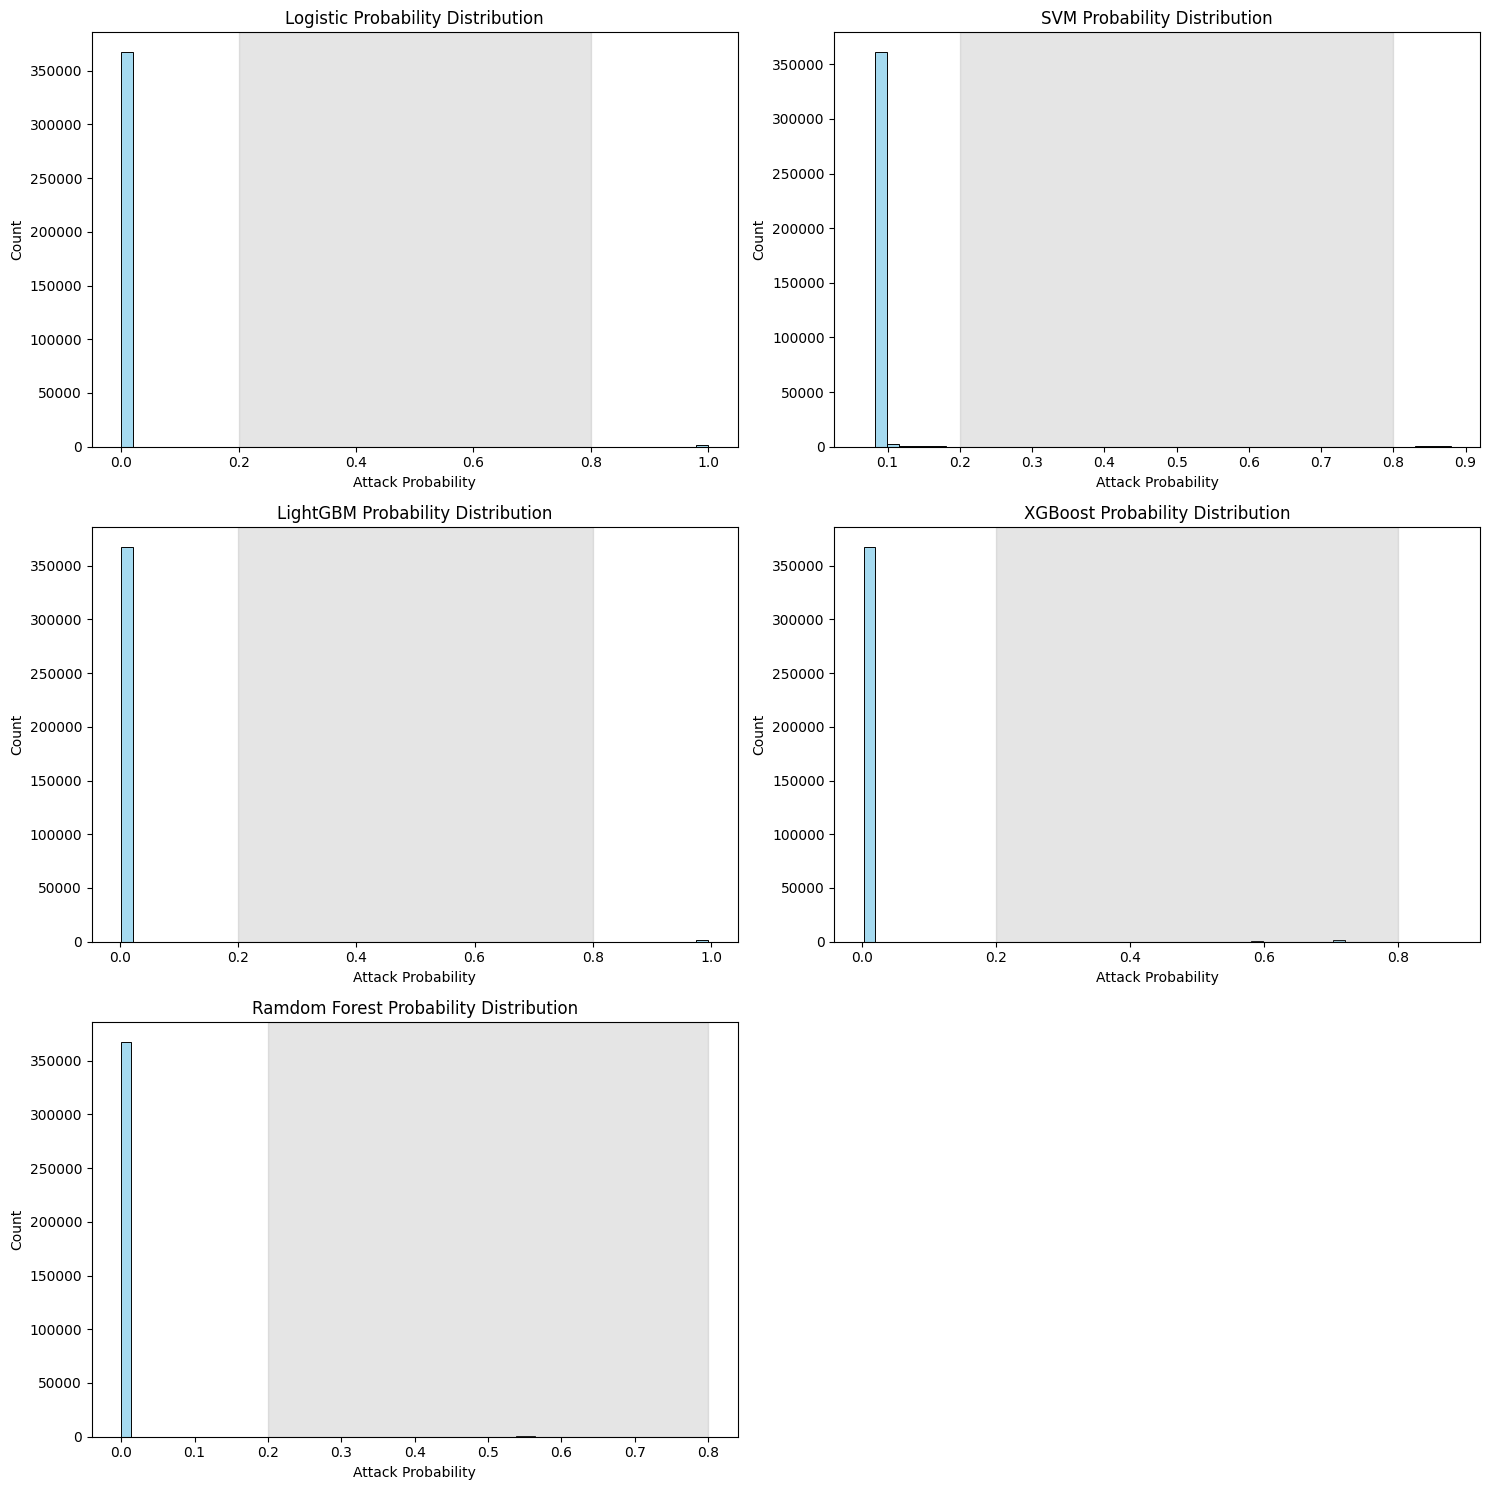

           Model  Accuracy  Uncertainty Rate (%)  Missed Attacks (FN)
0       Logistic  0.997057              0.067154                  119
1            SVM  0.997300              0.200651                    9
2       LightGBM  0.997100              0.048200                  108
3        XGBoost  0.997094              0.551587                  137
4  Ramdom Forest  0.997094              0.551858                  125


In [54]:
models = {
    "Logistic": joblib.load(os.path.join(MODEL_DIR, "layer1_logistic.pkl")),
    "SVM": joblib.load(os.path.join(MODEL_DIR, "layer1_svm.pkl")),
    "LightGBM": joblib.load(os.path.join(MODEL_DIR, "layer1_lightgbm.pkl")),
    "XGBoost": joblib.load(os.path.join(MODEL_DIR, "layer1_xgboost.pkl")),
    "Ramdom Forest": joblib.load(os.path.join(MODEL_DIR, "layer1_random_forest.pkl"))
}

def evaluate_candidates(models, X, y):
    results = []
    plt.figure(figsize=(15, 15)) 
    
    for i, (name, model) in enumerate(models.items()):
        probs = model.predict_proba(X)[:, 1]
        preds = (probs > 0.5).astype(int)
        
        uncertain_mask = (probs > 0.2) & (probs < 0.8)
        uncertain_rate = uncertain_mask.mean() * 100
        
        cm = confusion_matrix(y, preds)
        fn = cm[1, 0] if cm.shape == (2, 2) else 0 
        
        results.append({
            "Model": name,
            "Accuracy": (y == preds).mean(),
            "Uncertainty Rate (%)": uncertain_rate,
            "Missed Attacks (FN)": fn
        })
        
        plt.subplot(3, 2, i+1) 
        sns.histplot(probs, bins=50, kde=False, color='skyblue')
        plt.title(f"{name} Probability Distribution")
        plt.axvspan(0.2, 0.8, color='gray', alpha=0.2, label='Grey Zone')
        plt.xlabel("Attack Probability")
        plt.ylim(0, None)

        del model
        gc.collect()

    plt.tight_layout()
    plt.show()
    return pd.DataFrame(results)

report = evaluate_candidates(models, X_val, y_val)
print(report)
clear_memory('train_lf', 'val_lf', 'test_lf')

In [55]:
# feed the whole dataset to see if tree based model performs better
all_features = [c for c in all_current_cols if c != 'target']
(train_f, val_f, test_f) = prepare_train_val_test(new_lf, all_features)
X_train_f, y_train_f = train_f
X_val_f, y_val_f = val_f

============= SPLIT REPORT =============
Train:  1723391 rows | Attack:  37.3%
Val:     369298 rows | Attack:   0.3%
Test:    369299 rows | Attack:  17.5%


In [56]:
# --- MODEL C: LightGBM ---
print("Training LightGBM Full...")
lgb_l1 = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,  
    importance_type='gain',
    n_jobs=-1,
    random_state=RANDOM_SEED
)
lgb_l1.fit(X_train_f, y_train_f)
joblib.dump(lgb_l1, os.path.join(MODEL_DIR, "layer1_lightgbm_full.pkl"))

# --- MODEL D: XGBoost ---
print("Training XGBoost Full...")
xgb_l1 = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    eval_metric='logloss',
    random_state=RANDOM_SEED
)
xgb_l1.fit(X_train_f, y_train_f)
joblib.dump(xgb_l1, os.path.join(MODEL_DIR, "layer1_xgboost_full.pkl"))

# --- MODEL E: Random Forest ---
print("Training Random Forest Full...")
rf_l1 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=RANDOM_SEED
)
rf_l1.fit(X_train_f, y_train_f)
joblib.dump(rf_l1, os.path.join(MODEL_DIR, "layer1_random_forest_full.pkl"))

print("\n[SUCCESS] models are trained and saved.")

Training LightGBM Full...
Training XGBoost Full...
Training Random Forest Full...

[SUCCESS] models are trained and saved.


In [57]:
def evaluate_final_comparison(pruned_models, full_models, X_pruned, X_full, y):
    results = []
    
    # Evaluate Pruned (Linear)
    for name, model in pruned_models.items():
        probs = model.predict_proba(X_pruned)[:, 1]
        results.append(calculate_metrics(name + " (Pruned)", probs, y))
        
    # Evaluate Full (Trees)
    for name, model in full_models.items():
        probs = model.predict_proba(X_full)[:, 1]
        results.append(calculate_metrics(name + " (Full)", probs, y))
        
    return pd.DataFrame(results)

def calculate_metrics(name, probs, y):
    preds = (probs > 0.5).astype(int)
    cm = confusion_matrix(y, preds)
    fn = cm[1, 0] if cm.shape == (2, 2) else 0
    uncertain_rate = ((probs > 0.2) & (probs < 0.8)).mean() * 100
    return {
        "Model": name,
        "Accuracy": (y == preds).mean(),
        "Uncertainty Rate (%)": uncertain_rate,
        "Missed Attacks (FN)": fn
    }

pruned_models = {
    "Logistic": joblib.load(os.path.join(MODEL_DIR, "layer1_logistic.pkl")),
    "SVM": joblib.load(os.path.join(MODEL_DIR, "layer1_svm.pkl"))
}
full_models = {
    "LightGBM_full": joblib.load(os.path.join(MODEL_DIR, "layer1_lightgbm_full.pkl")),
    "XGBoost_full": joblib.load(os.path.join(MODEL_DIR, "layer1_xgboost_full.pkl")),
    "Ramdom_Forest_full": joblib.load(os.path.join(MODEL_DIR, "layer1_random_forest_full.pkl"))
}

# Run evaluation on Validation Set
report = evaluate_final_comparison(pruned_models, full_models, X_val, X_val_f, y_val)
print(report)

/home/nonroot/work/mlz_cap_2/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


                       Model  Accuracy  Uncertainty Rate (%)  \
0          Logistic (Pruned)  0.997057              0.067154   
1               SVM (Pruned)  0.997300              0.200651   
2       LightGBM_full (Full)  0.997094              0.135121   
3        XGBoost_full (Full)  0.997103              0.509616   
4  Ramdom_Forest_full (Full)  0.997097              0.540485   

   Missed Attacks (FN)  
0                  119  
1                    9  
2                  149  
3                  141  
4                  124  


## finetune

In [58]:
svm_model = joblib.load(os.path.join(MODEL_DIR, "layer1_svm.pkl"))
probs = svm_model.predict_proba(X_val)[:, 1]
attack_probs = probs[y_val == 1]

min_attack_prob = attack_probs.min()
print(f"min attack probability: {min_attack_prob:.6f}")

min attack probability: 0.095630


In [59]:
results = []

for c_val in [0.1, 1.0, 10.0]:
    base = LinearSVC(C=c_val, dual=False, max_iter=5000, random_state=RANDOM_SEED)
    clf = CalibratedClassifierCV(base, cv=5, method='sigmoid') 
    clf.fit(X_train, y_train)
    
    probs = clf.predict_proba(X_val)[:, 1]
    
    metrics = calculate_metrics(f"SVM (C={c_val})", probs, y_val)
    results.append(metrics)

final_report = pd.DataFrame(results)
print(final_report)

          Model  Accuracy  Uncertainty Rate (%)  Missed Attacks (FN)
0   SVM (C=0.1)  0.996916              0.217169                    8
1   SVM (C=1.0)  0.996900              0.316547                    8
2  SVM (C=10.0)  0.996886              0.316276                    8


In [60]:
# c = 10.0 likely produce overfited model
# also looks like the svm model above tho perform well(low false negative)
# the accuracy 0.99 is likely too biased toward one side
# in above i specify(method = "sigmoid") result in the prob dropping but it's more realistic